In [281]:
import pandas as pd
import numpy  as np

In [282]:
df= pd.read_csv(r'https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/refs/heads/main/Employee-Attrition.csv')

### Pre-pare the data

In [283]:
X = df.drop(columns=['Attrition'])
y= df['Attrition']
y = y.map({'Yes':1,'No':0})

In [284]:
categorical_col = X.select_dtypes(include='object').columns
numerical_col   = X.select_dtypes(exclude='object').columns

In [285]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

**Create Pipeline for Transforming the Data**

In [286]:
numerical_pipeline = Pipeline(steps=[
                        ("imputer",SimpleImputer(strategy="mean")),
                        ("scaler",StandardScaler())
                    ])

categorical_pipeline = Pipeline(steps=[
                        ("imputer",SimpleImputer(strategy="most_frequent")),
                        ("onehot",OneHotEncoder())
                    ])


preprocessor = ColumnTransformer(transformers=[
                                ("num",numerical_pipeline, numerical_col),
                                ("cat",categorical_pipeline,categorical_col)
                            ])


preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSala...
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot', OneHotEncoder())]),
                                 Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object'))])

**Use the Pipeline**

In [287]:
X_transformed = preprocessor.fit_transform(X)
X_transformed_df = pd.DataFrame(X_transformed, columns=preprocessor.get_feature_names_out())

In [288]:
# Lets use Train and Test as hold-out results

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_transformed_df, y, test_size=0.15, random_state=42)

**Train the Baseline**

In [289]:
from sklearn.linear_model import LogisticRegression


lr= LogisticRegression()
lr.fit(X_train,y_train)

y_preds       = lr.predict(X_test)
y_preds_proba_lr = lr.predict_proba(X_test)

In [290]:
y_preds_proba_positive = y_preds_proba_lr[:, 1]

In [291]:
import numpy as np
np.set_printoptions(suppress=True, precision=4)

In [292]:
y_preds_proba_positive

array([0.0626, 0.0033, 0.3447, 0.0106, 0.0498, 0.3546, 0.4036, 0.0343,
       0.0514, 0.02  , 0.5216, 0.0433, 0.0788, 0.0474, 0.0217, 0.0972,
       0.1393, 0.1394, 0.1518, 0.0375, 0.5309, 0.003 , 0.0376, 0.4658,
       0.1199, 0.0195, 0.0795, 0.0131, 0.0813, 0.0368, 0.0084, 0.003 ,
       0.0024, 0.025 , 0.4709, 0.004 , 0.0005, 0.2032, 0.8637, 0.019 ,
       0.0618, 0.1175, 0.0362, 0.0517, 0.7179, 0.009 , 0.7538, 0.5455,
       0.5762, 0.4526, 0.011 , 0.1614, 0.0075, 0.0792, 0.1192, 0.0784,
       0.3762, 0.0014, 0.0372, 0.0894, 0.027 , 0.5251, 0.021 , 0.0009,
       0.1919, 0.6087, 0.0244, 0.1179, 0.0114, 0.1537, 0.1884, 0.0579,
       0.283 , 0.0795, 0.0544, 0.0064, 0.0225, 0.119 , 0.1937, 0.127 ,
       0.0002, 0.2192, 0.0271, 0.1716, 0.0677, 0.0332, 0.2279, 0.1447,
       0.0163, 0.043 , 0.0053, 0.059 , 0.4114, 0.4618, 0.0409, 0.0593,
       0.021 , 0.1127, 0.1611, 0.0813, 0.0718, 0.0011, 0.005 , 0.1059,
       0.0116, 0.0755, 0.0027, 0.3177, 0.044 , 0.0046, 0.6683, 0.6665,
      

In [293]:
y_preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0])

In [294]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,ConfusionMatrixDisplay, classification_report,precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt

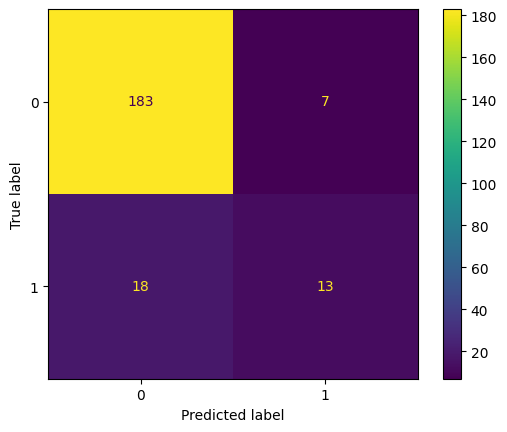

In [295]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_preds)).plot();

In [296]:
classification_report(y_preds,y_test)

'              precision    recall  f1-score   support\n\n           0       0.96      0.91      0.94       201\n           1       0.42      0.65      0.51        20\n\n    accuracy                           0.89       221\n   macro avg       0.69      0.78      0.72       221\nweighted avg       0.91      0.89      0.90       221\n'

In [297]:
print(classification_report(y_preds,y_test))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94       201
           1       0.42      0.65      0.51        20

    accuracy                           0.89       221
   macro avg       0.69      0.78      0.72       221
weighted avg       0.91      0.89      0.90       221



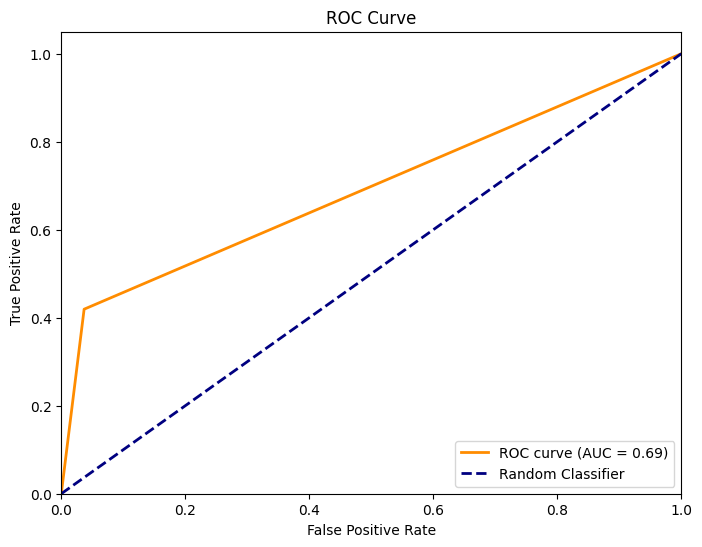

In [298]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_preds)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [299]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt


results = {}


def performance_metrics(
    y_test,
    y_preds,
    y_pred_proba,
    model_name: str
):

    # -----------------------------------
    # Classification Metrics
    # -----------------------------------

    accuracy = accuracy_score(
        y_test,
        y_preds
    )

    precision = precision_score(
        y_test,
        y_preds
    )

    recall = recall_score(
        y_test,
        y_preds
    )

    f1 = f1_score(
        y_test,
        y_preds
    )

    # -----------------------------------
    # Probability-based Metrics
    # -----------------------------------

    roc_auc = roc_auc_score(
        y_test,
        y_pred_proba
    )

    pr_auc = average_precision_score(
        y_test,
        y_pred_proba
    )

    # -----------------------------------
    # Store Results
    # -----------------------------------

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc
    }

    # -----------------------------------
    # Print Results
    # -----------------------------------

    print(f"\n{'=' * 50}")
    print(f"{model_name}")
    print(f"{'=' * 50}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")
    print(f"PR AUC   : {pr_auc:.4f}")

    # -----------------------------------
    # Confusion Matrix
    # -----------------------------------

    print("\nConfusion Matrix")

    ConfusionMatrixDisplay(
        confusion_matrix(
            y_test,
            y_preds
        )
    ).plot()

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.show()

    # -----------------------------------
    # Classification Report
    # -----------------------------------

    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            y_preds
        )
    )

    # -----------------------------------
    # ROC Curve
    # -----------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_pred_proba
    )

    plt.figure(figsize=(8, 6))

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'ROC Curve (AUC = {roc_auc:.2f})'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        lw=2,
        linestyle='--',
        label='Random Classifier'
    )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"{model_name} - ROC Curve"
    )

    plt.legend(
        loc="lower right"
    )

    plt.show()


LogisticRegression
Accuracy : 0.8869
Precision: 0.6500
Recall   : 0.4194
F1 Score : 0.5098
ROC AUC  : 0.7745
PR AUC   : 0.5347

Confusion Matrix


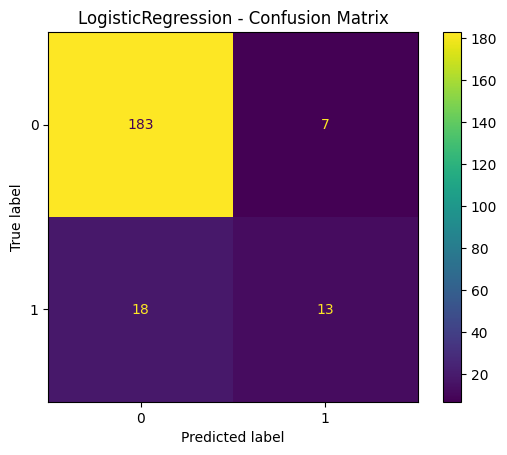


Classification Report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       190
           1       0.65      0.42      0.51        31

    accuracy                           0.89       221
   macro avg       0.78      0.69      0.72       221
weighted avg       0.87      0.89      0.88       221



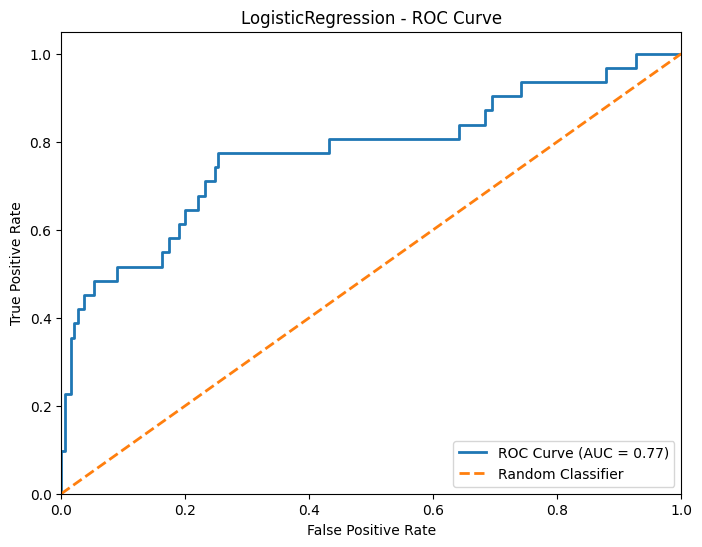

{'LogisticRegression': {'Accuracy': 0.8868778280542986,
  'Precision': 0.65,
  'Recall': 0.41935483870967744,
  'F1 Score': 0.5098039215686274,
  'ROC AUC': np.float64(0.7745331069609507),
  'PR AUC': np.float64(0.5347199600304198)}}

In [300]:
performance_metrics(y_test, y_preds,y_preds_proba_positive,'LogisticRegression')
results

**Decision Tree**


DecisionTreeClassifier
Accuracy : 0.8597
Precision: 0.5000
Recall   : 0.0323
F1 Score : 0.0606
ROC AUC  : 0.5838
PR AUC   : 0.1969

Confusion Matrix


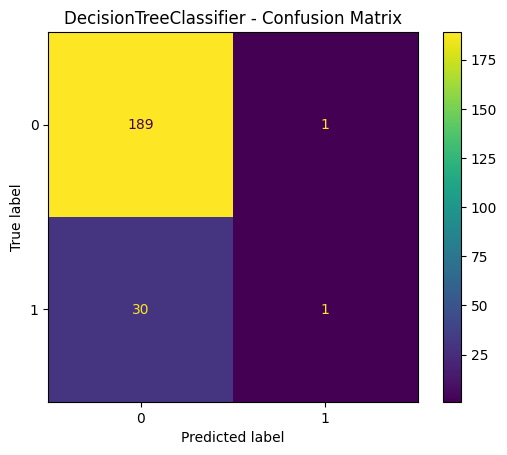


Classification Report
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       190
           1       0.50      0.03      0.06        31

    accuracy                           0.86       221
   macro avg       0.68      0.51      0.49       221
weighted avg       0.81      0.86      0.80       221



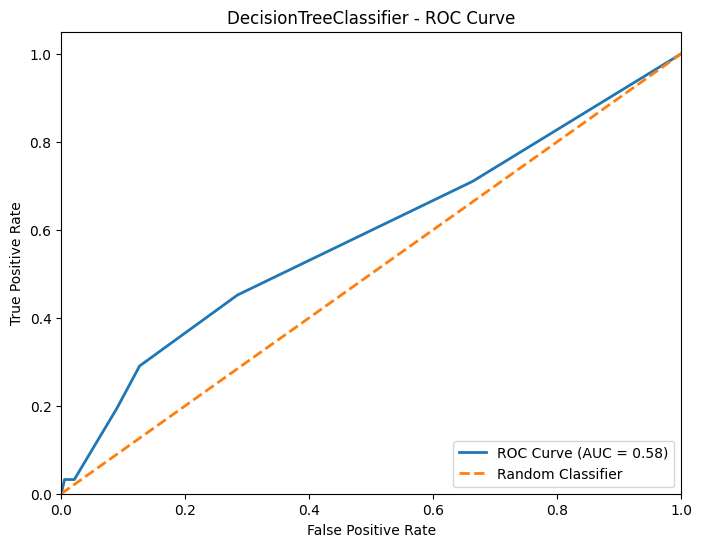

{'LogisticRegression': {'Accuracy': 0.8868778280542986,
  'Precision': 0.65,
  'Recall': 0.41935483870967744,
  'F1 Score': 0.5098039215686274,
  'ROC AUC': np.float64(0.7745331069609507),
  'PR AUC': np.float64(0.5347199600304198)},
 'DecisionTreeClassifier': {'Accuracy': 0.8597285067873304,
  'Precision': 0.5,
  'Recall': 0.03225806451612903,
  'F1 Score': 0.06060606060606061,
  'ROC AUC': np.float64(0.583786078098472),
  'PR AUC': np.float64(0.1968894850670282)}}

In [301]:
from sklearn.tree import DecisionTreeClassifier


dt = DecisionTreeClassifier(max_depth=3,random_state=42)
dt.fit(X_train, y_train)
y_preds_dt = dt.predict(X_test)
y_preds_proba_dt = dt.predict_proba(X_test)[:, 1]
performance_metrics(y_test, y_preds_dt,y_preds_proba_dt,'DecisionTreeClassifier')
results

**Random Forest**


RandomForest
Accuracy : 0.8733
Precision: 0.7143
Recall   : 0.1613
F1 Score : 0.2632
ROC AUC  : 0.7228
PR AUC   : 0.4120

Confusion Matrix


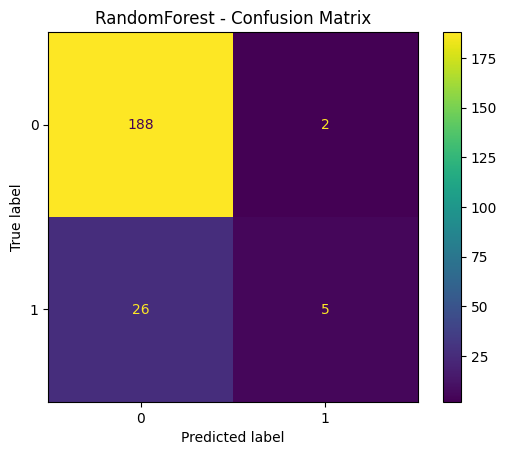


Classification Report
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       190
           1       0.71      0.16      0.26        31

    accuracy                           0.87       221
   macro avg       0.80      0.58      0.60       221
weighted avg       0.86      0.87      0.84       221



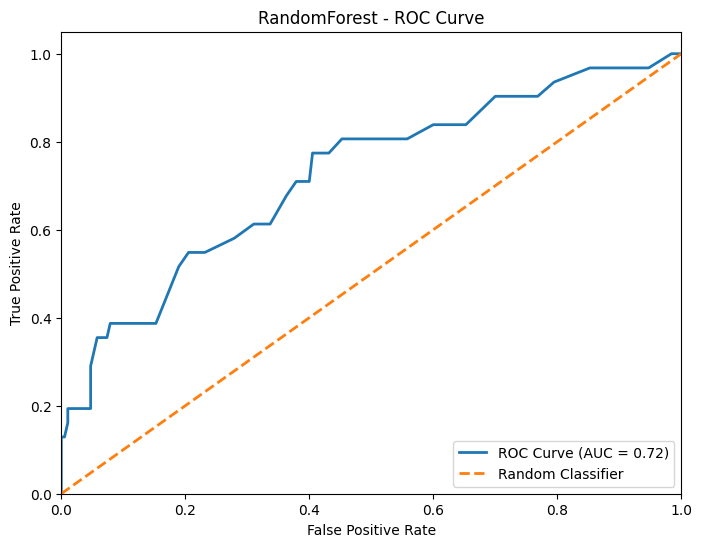

{'LogisticRegression': {'Accuracy': 0.8868778280542986,
  'Precision': 0.65,
  'Recall': 0.41935483870967744,
  'F1 Score': 0.5098039215686274,
  'ROC AUC': np.float64(0.7745331069609507),
  'PR AUC': np.float64(0.5347199600304198)},
 'DecisionTreeClassifier': {'Accuracy': 0.8597285067873304,
  'Precision': 0.5,
  'Recall': 0.03225806451612903,
  'F1 Score': 0.06060606060606061,
  'ROC AUC': np.float64(0.583786078098472),
  'PR AUC': np.float64(0.1968894850670282)},
 'RandomForest': {'Accuracy': 0.8733031674208145,
  'Precision': 0.7142857142857143,
  'Recall': 0.16129032258064516,
  'F1 Score': 0.2631578947368421,
  'ROC AUC': np.float64(0.7227504244482172),
  'PR AUC': np.float64(0.41199893473875104)}}

In [302]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_preds_rfe = rf.predict(X_test)
y_preds_proba_rfe = rf.predict_proba(X_test)[:, 1]
performance_metrics(y_test, y_preds_rfe,y_preds_proba_rfe,'RandomForest')
results

**Voting Classifier**


VotingClassifier
Accuracy : 0.8733
Precision: 0.7143
Recall   : 0.1613
F1 Score : 0.2632
ROC AUC  : 0.7261
PR AUC   : 0.3989

Confusion Matrix


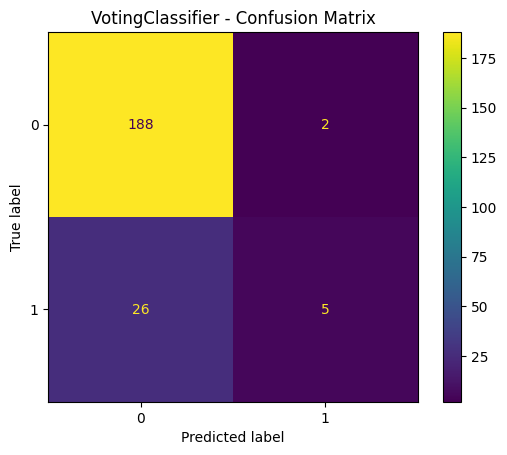


Classification Report
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       190
           1       0.71      0.16      0.26        31

    accuracy                           0.87       221
   macro avg       0.80      0.58      0.60       221
weighted avg       0.86      0.87      0.84       221



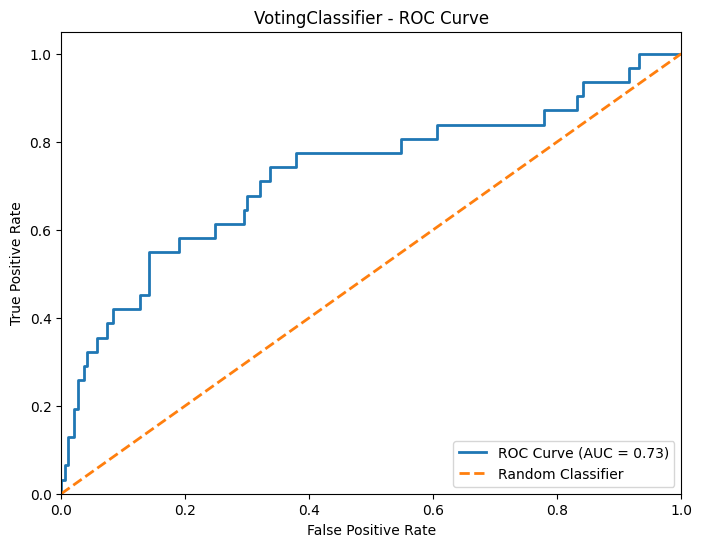

{'LogisticRegression': {'Accuracy': 0.8868778280542986,
  'Precision': 0.65,
  'Recall': 0.41935483870967744,
  'F1 Score': 0.5098039215686274,
  'ROC AUC': np.float64(0.7745331069609507),
  'PR AUC': np.float64(0.5347199600304198)},
 'DecisionTreeClassifier': {'Accuracy': 0.8597285067873304,
  'Precision': 0.5,
  'Recall': 0.03225806451612903,
  'F1 Score': 0.06060606060606061,
  'ROC AUC': np.float64(0.583786078098472),
  'PR AUC': np.float64(0.1968894850670282)},
 'RandomForest': {'Accuracy': 0.8733031674208145,
  'Precision': 0.7142857142857143,
  'Recall': 0.16129032258064516,
  'F1 Score': 0.2631578947368421,
  'ROC AUC': np.float64(0.7227504244482172),
  'PR AUC': np.float64(0.41199893473875104)},
 'VotingClassifier': {'Accuracy': 0.8733031674208145,
  'Precision': 0.7142857142857143,
  'Recall': 0.16129032258064516,
  'F1 Score': 0.2631578947368421,
  'ROC AUC': np.float64(0.7261460101867572),
  'PR AUC': np.float64(0.39887359768817937)}}

In [303]:
from sklearn.ensemble import VotingClassifier


# Define individual models
logistic = LogisticRegression(
    max_iter=1000
)

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Create Voting Classifier
voting_clf = VotingClassifier(
              estimators=[
                  ('lr', logistic),
                  ('dt', decision_tree),
                  ('rf', random_forest)
              ],
              voting='soft'
          )


# Train
voting_clf.fit(X_train, y_train)

# Predict
y_pred_voting = voting_clf.predict(X_test)

rf.fit(X_train, y_train)
y_pred_voting         = voting_clf.predict(X_test)
y_pred_proba_voting   = voting_clf.predict_proba(X_test)[:, 1]
performance_metrics(y_test, y_preds_rf,y_pred_proba_voting,'VotingClassifier')
results


Stacking
Accuracy : 0.9005
Precision: 0.8462
Recall   : 0.3548
F1 Score : 0.5000
ROC AUC  : 0.7643
PR AUC   : 0.5253

Confusion Matrix


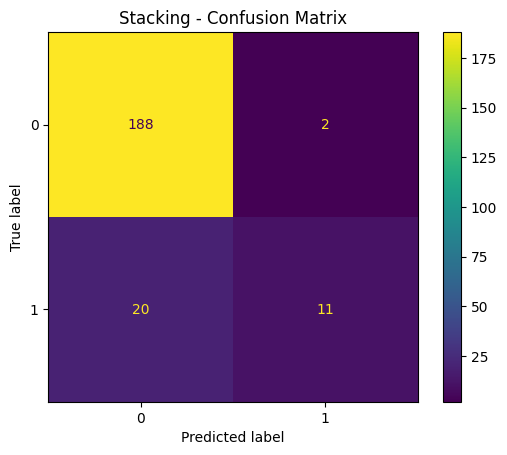


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       190
           1       0.85      0.35      0.50        31

    accuracy                           0.90       221
   macro avg       0.88      0.67      0.72       221
weighted avg       0.90      0.90      0.88       221



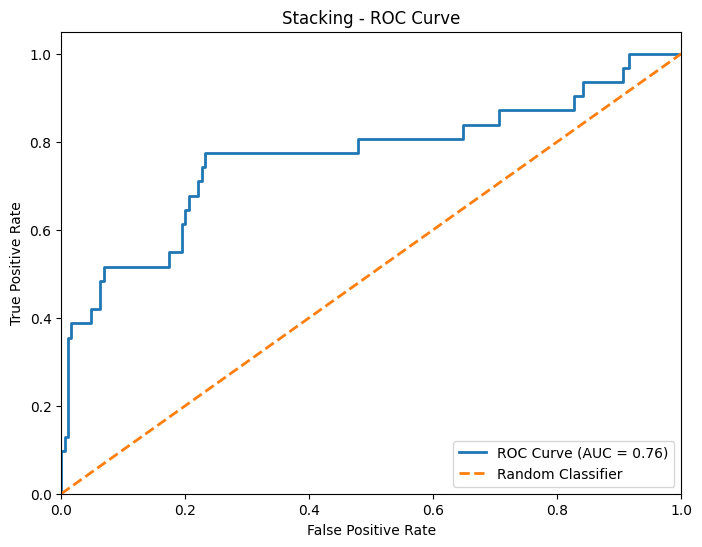

{'LogisticRegression': {'Accuracy': 0.8868778280542986,
  'Precision': 0.65,
  'Recall': 0.41935483870967744,
  'F1 Score': 0.5098039215686274,
  'ROC AUC': np.float64(0.7745331069609507),
  'PR AUC': np.float64(0.5347199600304198)},
 'DecisionTreeClassifier': {'Accuracy': 0.8597285067873304,
  'Precision': 0.5,
  'Recall': 0.03225806451612903,
  'F1 Score': 0.06060606060606061,
  'ROC AUC': np.float64(0.583786078098472),
  'PR AUC': np.float64(0.1968894850670282)},
 'RandomForest': {'Accuracy': 0.8733031674208145,
  'Precision': 0.7142857142857143,
  'Recall': 0.16129032258064516,
  'F1 Score': 0.2631578947368421,
  'ROC AUC': np.float64(0.7227504244482172),
  'PR AUC': np.float64(0.41199893473875104)},
 'VotingClassifier': {'Accuracy': 0.8733031674208145,
  'Precision': 0.7142857142857143,
  'Recall': 0.16129032258064516,
  'F1 Score': 0.2631578947368421,
  'ROC AUC': np.float64(0.7261460101867572),
  'PR AUC': np.float64(0.39887359768817937)},
 'Stacking': {'Accuracy': 0.90045248868

In [304]:
from sklearn.ensemble import StackingClassifier

# Base models
logistic = LogisticRegression(
    max_iter=1000
)

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', logistic),
        ('dt', decision_tree),
        ('rf', random_forest)
    ],
    final_estimator=LogisticRegression(
        max_iter=1000
    ),
    cv=5
)

# Train
stacking_clf.fit(X_train, y_train)

# Predict
y_pred_stack = stacking_clf.predict(X_test)

# Probability
y_pred_proba_stack = stacking_clf.predict_proba(X_test)[:, 1]

performance_metrics(y_test, y_pred_stack,y_pred_proba_stack,'Stacking')
results

**Boosting**


Boosting Ensemble
Accuracy : 0.8688
Precision: 0.6000
Recall   : 0.1935
F1 Score : 0.2927
ROC AUC  : 0.7194
PR AUC   : 0.4202

Confusion Matrix


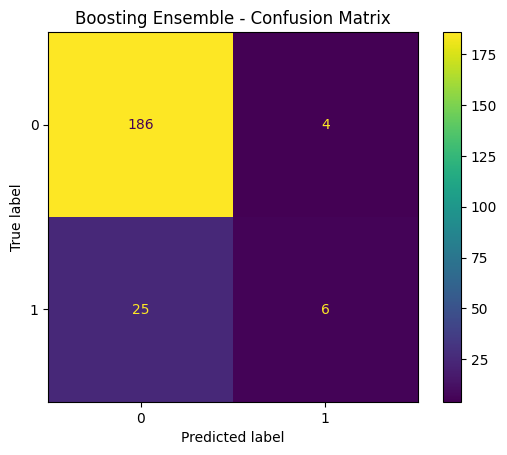


Classification Report
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       190
           1       0.60      0.19      0.29        31

    accuracy                           0.87       221
   macro avg       0.74      0.59      0.61       221
weighted avg       0.84      0.87      0.84       221



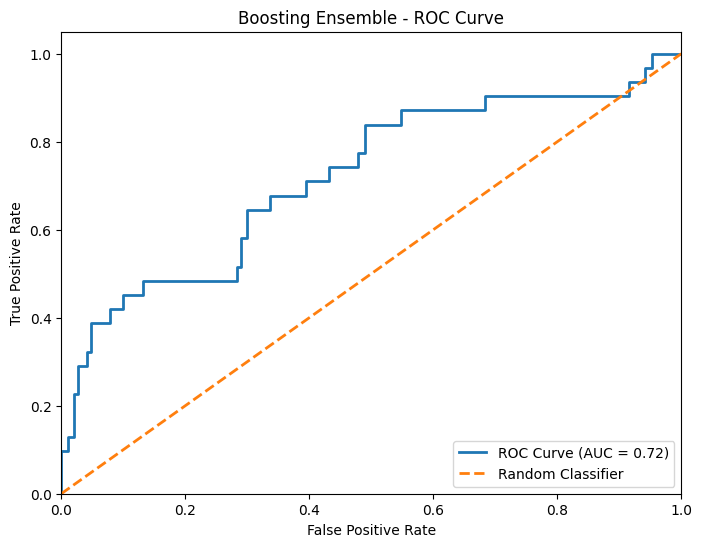

{'LogisticRegression': {'Accuracy': 0.8868778280542986,
  'Precision': 0.65,
  'Recall': 0.41935483870967744,
  'F1 Score': 0.5098039215686274,
  'ROC AUC': np.float64(0.7745331069609507),
  'PR AUC': np.float64(0.5347199600304198)},
 'DecisionTreeClassifier': {'Accuracy': 0.8597285067873304,
  'Precision': 0.5,
  'Recall': 0.03225806451612903,
  'F1 Score': 0.06060606060606061,
  'ROC AUC': np.float64(0.583786078098472),
  'PR AUC': np.float64(0.1968894850670282)},
 'RandomForest': {'Accuracy': 0.8733031674208145,
  'Precision': 0.7142857142857143,
  'Recall': 0.16129032258064516,
  'F1 Score': 0.2631578947368421,
  'ROC AUC': np.float64(0.7227504244482172),
  'PR AUC': np.float64(0.41199893473875104)},
 'VotingClassifier': {'Accuracy': 0.8733031674208145,
  'Precision': 0.7142857142857143,
  'Recall': 0.16129032258064516,
  'F1 Score': 0.2631578947368421,
  'ROC AUC': np.float64(0.7261460101867572),
  'PR AUC': np.float64(0.39887359768817937)},
 'Stacking': {'Accuracy': 0.90045248868

In [305]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gb_clf.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_clf.predict(X_test)
y_pred_proba_gb = gb_clf.predict_proba(X_test)[:, 1]

performance_metrics(y_test, y_pred_gb,y_pred_proba_gb,'Boosting Ensemble')
results

In [306]:
pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
LogisticRegression,0.89,0.65,0.42,0.51,0.77,0.53
DecisionTreeClassifier,0.86,0.50,0.03,0.06,0.58,0.20
RandomForest,0.87,0.71,0.16,0.26,0.72,0.41
VotingClassifier,0.87,0.71,0.16,0.26,0.73,0.40
Stacking,0.90,0.85,0.35,0.50,0.76,0.53
Boosting Ensemble,0.87,0.60,0.19,0.29,0.72,0.42


precision  when model say churned how correct
recall - out of the churned 1 how many did our model correct identify

In [307]:
y.value_counts(normalize=True)

,proportion
Attrition,
0,0.84
1,0.16


Introduce Cost

- Cost of missing a churner       (FN)   = **KES 10,000**
- Cost of unnecessary intervention (FP)  = **KES 800**

$$Cost=FN(10,000)+FP(800)$$

$10,000 ≫ 800$

a missed churner is 12.5 times more expensive than an unnecessary intervention.That fundamentally changes which model we prefer.

**Turn the model into a cost function**

In [308]:
from sklearn.metrics import confusion_matrix

def calculate_business_cost(y_test, y_pred,
                            fn_cost=10_000,
                            fp_cost=800):

    tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()

    total_cost = (fn * fn_cost+ fp * fp_cost)

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FN Cost": fn * fn_cost,
        "FP Cost": fp * fp_cost,
        "Total Cost": total_cost
    }

In [313]:
cost_results = {}

cost_results["Logistic Regression"] = calculate_business_cost(
    y_test,
    y_preds
)

cost_results["Decision Tree"] = calculate_business_cost(
    y_test,
    y_preds_dt
)

cost_results["Random Forest"] = calculate_business_cost(
    y_test,
    y_preds_rfe
)

cost_results["Voting"] = calculate_business_cost(
    y_test,
    y_pred_voting
)

cost_results["Stacking"] = calculate_business_cost(
    y_test,
    y_pred_stack
)

cost_results["Boosting"] = calculate_business_cost(
    y_test,
    y_pred_gb
)

In [314]:
cost_df = pd.DataFrame(cost_results).T

cost_df.sort_values(
    "Total Cost"
)

,TN,FP,FN,TP,FN Cost,FP Cost,Total Cost
Logistic Regression,183,7,18,13,180000,5600,185600
Stacking,188,2,20,11,200000,1600,201600
Voting,185,5,24,7,240000,4000,244000
Boosting,186,4,25,6,250000,3200,253200
Random Forest,188,2,26,5,260000,1600,261600
Decision Tree,189,1,30,1,300000,800,300800


In [319]:

# --------------------------------------------------
# 1. Probability of positive class
# --------------------------------------------------

y_pred_proba = y_preds_proba_lr[:, 1]


# --------------------------------------------------
# 2. Threshold-independent metrics
# --------------------------------------------------

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

pr_auc = average_precision_score(
    y_test,
    y_pred_proba
)


# --------------------------------------------------
# 3. Test thresholds
# --------------------------------------------------

FN_COST = 10_000
FP_COST = 800

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:

    # Convert probability into class prediction
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Business cost
    total_cost = (
        fp * FP_COST +
        fn * FN_COST
    )

    results.append({
        "threshold": threshold,

        # Confusion matrix
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,

        # Classification metrics
        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        # Business metrics
        "FP_cost": fp * FP_COST,
        "FN_cost": fn * FN_COST,
        "total_cost": total_cost,

        # Threshold-independent metrics
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc
    })


threshold_results = pd.DataFrame(results)
threshold_results

,threshold,TP,FP,TN,FN,precision,recall,f1,FP_cost,FN_cost,total_cost,ROC_AUC,PR_AUC
0,0.01,29,156,34,2,0.16,0.94,0.27,124800,20000,144800,0.77,0.53
1,0.02,28,136,54,3,0.17,0.90,0.29,108800,30000,138800,0.77,0.53
2,0.03,25,120,70,6,0.17,0.81,0.28,96000,60000,156000,0.77,0.53
3,0.04,25,107,83,6,0.19,0.81,0.31,85600,60000,145600,0.77,0.53
4,0.05,25,97,93,6,0.20,0.81,0.33,77600,60000,137600,0.77,0.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.95,0,0,190,31,0.00,0.00,0.00,0,310000,310000,0.77,0.53
95,0.96,0,0,190,31,0.00,0.00,0.00,0,310000,310000,0.77,0.53
96,0.97,0,0,190,31,0.00,0.00,0.00,0,310000,310000,0.77,0.53
97,0.98,0,0,190,31,0.00,0.00,0.00,0,310000,310000,0.77,0.53


In [320]:
optimal_result = threshold_results.loc[
    threshold_results["total_cost"].idxmin()
]

optimal_result

,11
threshold,0.12
TP,24.00
FP,50.00
TN,140.00
FN,7.00
precision,0.32
recall,0.77
f1,0.46
FP_cost,40000.00
FN_cost,70000.00


In [321]:
threshold_results.sort_values(
    "total_cost"
)[
    [
        "threshold",
        "TP",
        "FP",
        "TN",
        "FN",
        "precision",
        "recall",
        "f1",
        "total_cost",
        "ROC_AUC",
        "PR_AUC"
    ]
].head(10)

,threshold,TP,FP,TN,FN,precision,recall,f1,total_cost,ROC_AUC,PR_AUC
11,0.12,24,50,140,7,0.32,0.77,0.46,110000,0.77,0.53
10,0.11,24,58,132,7,0.29,0.77,0.42,116400,0.77,0.53
12,0.13,23,48,142,8,0.32,0.74,0.45,118400,0.77,0.53
9,0.10,24,61,129,7,0.28,0.77,0.41,118800,0.77,0.53
8,0.09,24,66,124,7,0.27,0.77,0.40,122800,0.77,0.53
7,0.08,24,69,121,7,0.26,0.77,0.39,125200,0.77,0.53
14,0.15,22,45,145,9,0.33,0.71,0.45,126000,0.77,0.53
13,0.14,22,47,143,9,0.32,0.71,0.44,127600,0.77,0.53
5,0.06,25,89,101,6,0.22,0.81,0.34,131200,0.77,0.53
6,0.07,24,80,110,7,0.23,0.77,0.36,134000,0.77,0.53
